In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

# Layer 3 Library: Vector Autoregression
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error

# Layer 2 Library: PC Algorithm
# (Requires: pip install causal-learn)
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.GraphUtils import GraphUtils

/Users/isabellamueller-vogt/Library/Mobile Documents/com~apple~CloudDocs/08 - side quests/network-dynamics-failure-propagation/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# STAGE 0: COMPLEX DATA GENERATION
np.random.seed(42)
continents = ['North America', 'Europe', 'Asia', 'South America', 'Africa']
samples_per_continent = 300 

all_data = []

for region in continents:
    # 1. Define Regional Biases
    bias_sleep = np.random.randint(-5, 5)
    bias_vo2 = np.random.randint(-5, 5)
    bias_glucose = np.random.randint(-5, 10)
    
    # Initialize Matrix (N days x 7 variables)
    data = np.zeros((samples_per_continent, 7))
    
    # Initial Baseline Values
    # Sleep(75), Mood(7), Act(5000), RHR(60), HRV(50), VO2(45), Gluc(90)
    data[0, :] = [75, 7, 5000, 60, 50, 45, 90]
    
    for t in range(1, samples_per_continent):
        # Fetch Yesterday's values
        p_sleep, p_mood, p_act, p_rhr, p_hrv, p_vo2, p_gluc = data[t-1, :]
        
        # --- THE BIOLOGICAL ENGINE ---
        
        # 1. SLEEP: Autoregressive + random variation
        new_sleep = 0.3 * p_sleep + 50 + np.random.normal(0, 8) + bias_sleep
        new_sleep = np.clip(new_sleep, 0, 100)
        
        # 2. HRV: Driven by SLEEP and MOOD
        new_hrv = 0.4 * p_hrv + 0.3 * (p_sleep - 50) + 2 * p_mood + np.random.normal(0, 5)
        
        # 3. RESTING HR (RHR): Inverse to HRV and Sleep
        new_rhr = 0.6 * p_rhr - 0.1 * (new_hrv - 50) - 0.1 * (p_sleep - 70) + np.random.normal(0, 2)
        
        # 4. MOOD: Driven by SLEEP and HRV
        new_mood = 0.4 * p_mood + 0.05 * p_sleep + np.random.normal(0, 1)
        new_mood = np.clip(new_mood, 1, 10)
        
        # 5. ACTIVITY: Driven by MOOD and VO2 Max
        new_act = 0.5 * p_act + 500 * p_mood + np.random.normal(0, 1000)
        
        # 6. VO2 MAX: Slow moving, driven by ACTIVITY history
        new_vo2 = 0.95 * p_vo2 + 0.0001 * p_act + np.random.normal(0, 0.2) + (bias_vo2 * 0.01)
        
        # 7. FASTING GLUCOSE: Inverse to ACTIVITY and SLEEP
        new_gluc = 0.7 * p_gluc - 0.001 * p_act - 0.1 * (p_sleep - 70) + 30 + np.random.normal(0, 3) + bias_glucose

        data[t, :] = [new_sleep, new_mood, new_act, new_rhr, new_hrv, new_vo2, new_gluc]

    df_region = pd.DataFrame(data, columns=['Sleep', 'Mood', 'Activity', 'RHR', 'HRV', 'VO2_Max', 'Glucose'])
    df_region['Continent'] = region
    all_data.append(df_region)

df_master = pd.concat(all_data).reset_index(drop=True)
print("Stage 0 Complete: Data Generated for 7 Parameters.")
print(df_master.describe().round(1).loc[['mean', 'std', 'min', 'max']])

Stage 0 Complete: Data Generated for 7 Parameters.
      Sleep  Mood  Activity   RHR   HRV  VO2_Max  Glucose
mean   70.2   5.8    5822.6   5.4  29.8     13.8     86.9
std     9.6   1.3    1547.9   5.5   8.2      6.0     19.7
min    41.9   1.2     616.3  -6.6  -0.1      7.0     45.3
max    99.9  10.0   10934.8  60.0  53.8     45.0    123.5


In [4]:
# STAGE 1: TRAIN/TEST SPLIT
test_continent = 'Asia'
train_cols = ['Sleep', 'Mood', 'Activity', 'RHR', 'HRV', 'VO2_Max', 'Glucose']

# Training Data: Everyone EXCEPT Asia
df_train = df_master[df_master['Continent'] != test_continent][train_cols]

# Test Data: ONLY Asia
df_test = df_master[df_master['Continent'] == test_continent][train_cols]

print(f"Stage 1 Complete: Data Split.")
print(f"   Training Samples: {len(df_train)}")
print(f"   Testing Samples: {len(df_test)} (Continent: {test_continent})")


Stage 1 Complete: Data Split.
   Training Samples: 1200
   Testing Samples: 300 (Continent: Asia)


Stage 2: Running PC Algorithm...


Depth=3, working on node 6: 100%|██████████| 7/7 [00:00<00:00, 2743.17it/s]


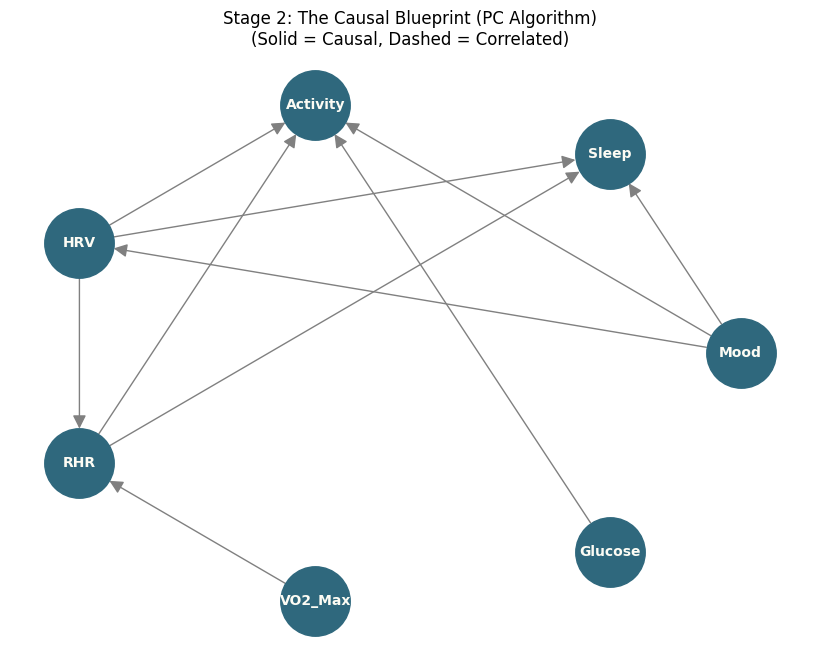

Stage 2 Complete: Causal Topology Discovered.


In [ ]:
# STAGE 2: CAUSAL DISCOVERY (PC Algorithm)

# This stage draws the "Skeleton" of the graph based on conditional independence.
# It tells us WHAT connects to WHAT, before we ask "how much" or "when".

from causallearn.search.ConstraintBased.PC import pc

print("Stage 2: Running PC Algorithm...")

# 1. Prepare Data
# PC requires a simple NumPy matrix of the training data
data_matrix = df_train.to_numpy()
labels = df_train.columns

# 2. Run the Algorithm
# alpha=0.05 is the standard statistical threshold (p-value)
# indep_test='fisherz' is the standard test for continuous data (like HR, Glucose)
cg = pc(data_matrix, alpha=0.05, indep_test='fisherz', verbose=False)

# 3. Visualization
# We convert the PC output into a NetworkX graph to draw it
G_pc = nx.DiGraph()
adj_matrix = cg.G.graph

for i in range(len(labels)):
    for j in range(len(labels)):
        # Interpretation of PC Output Matrix:
        # [j, i] == 1 AND [i, j] == -1  =>  Directed Edge (i -> j)
        if adj_matrix[j, i] == 1 and adj_matrix[i, j] == -1:
            G_pc.add_edge(labels[i], labels[j])
            
        # [j, i] == -1 AND [i, j] == -1 =>  Undirected Edge (Correlation found, direction unclear)
        elif adj_matrix[i, j] == -1 and adj_matrix[j, i] == -1:
            if i < j: # Avoid duplicates
                G_pc.add_edge(labels[i], labels[j], style='dashed')

# 4. Plotting
plt.figure(figsize=(8, 6))

# Use circular layout because we have 7 nodes (prevents a messy hairball)
pos = nx.circular_layout(G_pc) 

nx.draw(G_pc, pos, with_labels=True, node_color='#2F687D', 
        node_size=2500, font_weight='bold', font_size=10, font_color='#FDFCF4',
        arrowsize=20, edge_color='gray')

plt.title("Stage 2: The Causal Blueprint (PC Algorithm)\n(Solid = Causal, Dashed = Correlated)")
plt.show()

print("Stage 2 Complete: Causal Topology Discovered.")

In [8]:
# STEP 3: LAYER 3 - TEMPORAL DYNAMICS (VAR Model)
# Goal: Quantify the *strength* and *timing* of the edges found in Layer 2.
model = VAR(df_train)

# We use Lag 2 here (looking back 2 days)
results = model.fit(maxlags=2) 

print("\nStage 3 Complete: Model Trained.")
print("   Checking Logic: Does 'Activity' lower 'Glucose'?")

# Row = The Cause (Activity yesterday -> L1.Activity)
# Column = The Effect (Glucose today)
coef = results.params.loc['L1.Activity', 'Glucose']

print(f"   Coefficient (Activity -> Glucose): {coef:.5f} ({'Correct (Negative)' if coef < 0 else 'Incorrect'})")


Stage 3 Complete: Model Trained.
   Checking Logic: Does 'Activity' lower 'Glucose'?
   Coefficient (Activity -> Glucose): -0.00079 (Correct (Negative))


/Users/isabellamueller-vogt/Library/Mobile Documents/com~apple~CloudDocs/08 - side quests/network-dynamics-failure-propagation/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


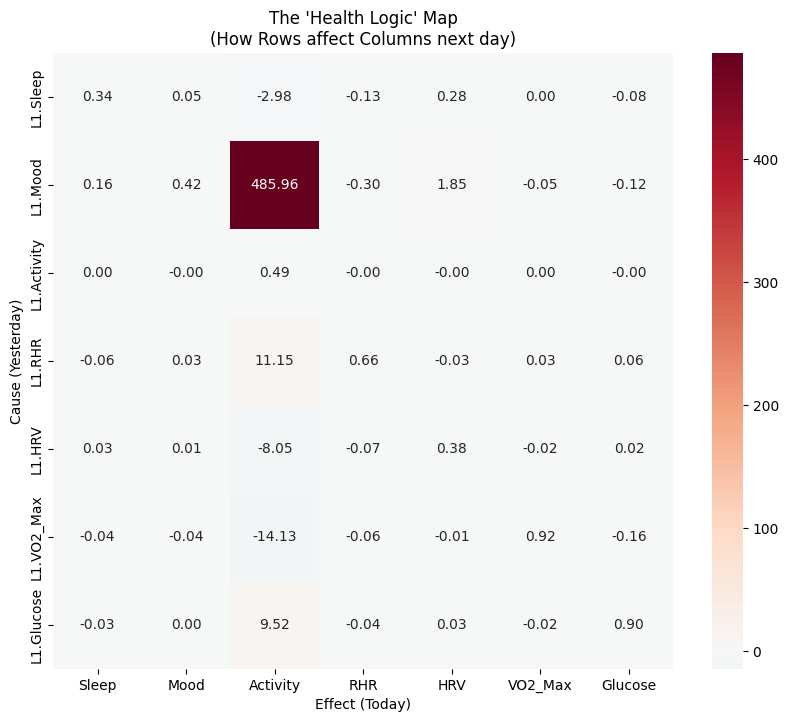

Stage 4 Complete: Heatmap generated.


In [9]:
# STAGE 4: VISUALIZE THE NETWORK

# Extract Lag-1 Causal Matrix (How Yesterday affects Today)
matrix_l1 = results.params.iloc[1:8, :] # Skip intercept row

plt.figure(figsize=(10, 8))
sns.heatmap(matrix_l1, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title("The 'Health Logic' Map\n(How Rows affect Columns next day)")
plt.ylabel("Cause (Yesterday)")
plt.xlabel("Effect (Today)")
plt.show()

print("Stage 4 Complete: Heatmap generated.")


Stage 5: Running Simulations...


<Figure size 1000x500 with 0 Axes>

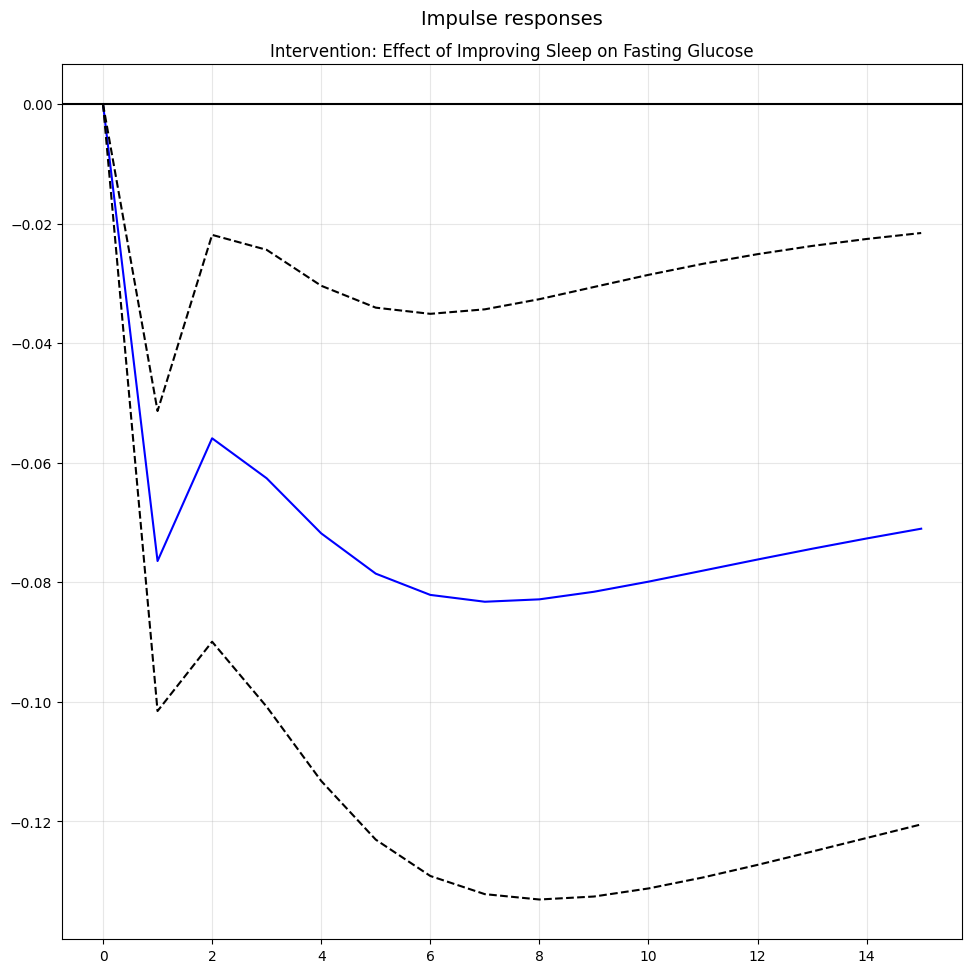

<Figure size 1000x500 with 0 Axes>

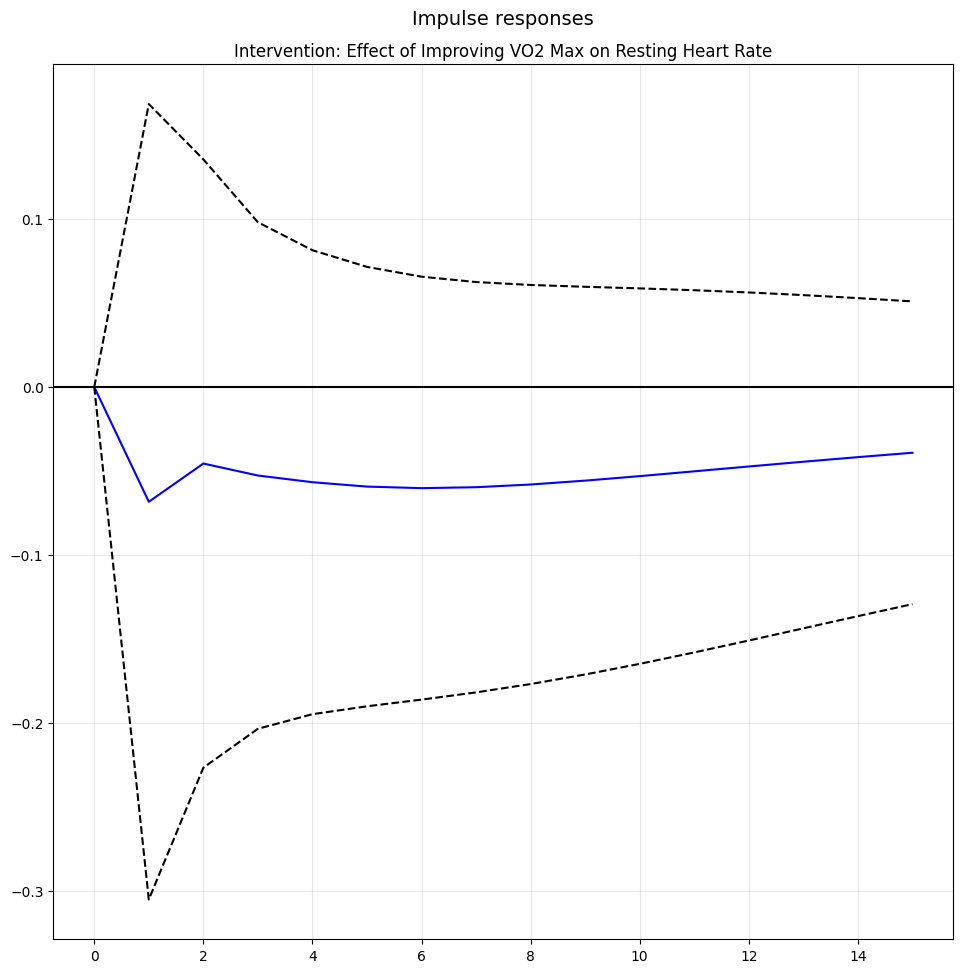

In [7]:
# STAGE 5: INTERVENTION SIMULATION
print("\nStage 5: Running Simulations...")

# Scenario 1: "If I force myself to Sleep better, what happens to my Glucose?"
irf = results.irf(15) # 15 days projection

plt.figure(figsize=(10, 5))
irf.plot(impulse='Sleep', response='Glucose')
plt.title("Intervention: Effect of Improving Sleep on Fasting Glucose")
plt.grid(True, alpha=0.3)
plt.show()

# Scenario 2: "If I improve my VO2 Max (get fitter), does my RHR go down?"
plt.figure(figsize=(10, 5))
irf.plot(impulse='VO2_Max', response='RHR')
plt.title("Intervention: Effect of Improving VO2 Max on Resting Heart Rate")
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
# ============================================================
# STAGE 5: INTERVENTION SIMULATION (Baseline vs Policy Path)
# ============================================================

print("\nStage 5: Running baseline vs intervention simulations on health system...")

var_names = list(df_train.columns)
k_ar = results.k_ar


# -------------------------------------------------------------------
# Helper: generic forward simulation of the VAR
# -------------------------------------------------------------------
def simulate_path(results, initial_history, horizon, intervention_fn=None):
    """
    Simulate a path of length `horizon` from a VAR model.

    Parameters
    ----------
    results : statsmodels.tsa.vector_ar.var_model.VARResults
        Fitted VAR model.
    initial_history : np.ndarray, shape (k_ar, n_vars)
        Last k_ar observations (in correct time order).
    horizon : int
        Number of future steps to simulate.
    intervention_fn : callable or None
        Function f(step_idx, y_pred) -> modified_y_pred.
        Called at each step AFTER the VAR one-step prediction.
        If None, no intervention is applied.

    Returns
    -------
    path : np.ndarray, shape (horizon, n_vars)
        Simulated future path.
    """
    history = initial_history.copy()
    n_vars = history.shape[1]
    path = []

    for step in range(horizon):
        # One-step-ahead forecast from current history
        y_pred = results.forecast(y=history, steps=1)[0]  # shape (n_vars,)

        # Apply intervention (policy) if provided
        if intervention_fn is not None:
            y_pred = intervention_fn(step, y_pred.copy())

        path.append(y_pred)

        # Roll history window forward: drop oldest, append new
        history = np.vstack([history[1:], y_pred])

    return np.array(path)  # shape (horizon, n_vars)


# -------------------------------------------------------------------
# Helper: detect when a trajectory crosses a critical threshold
# -------------------------------------------------------------------
def first_crossing(series, threshold, direction="above"):
    """
    Return the first time index t where series crosses threshold.

    Parameters
    ----------
    series : 1D array-like
        Time series values.
    threshold : float
        Threshold value.
    direction : {'above', 'below'}
        'above'  => series[t] >= threshold
        'below'  => series[t] <= threshold

    Returns
    -------
    idx : int or None
        First index where condition is met, or None if never crosses.
    """
    series = np.asarray(series)
    if direction == "above":
        mask = series >= threshold
    else:
        mask = series <= threshold

    if not mask.any():
        return None

    return int(np.argmax(mask))


# -------------------------------------------------------------------
# Higher-level helper: run one driver→target intervention scenario
# -------------------------------------------------------------------
def run_intervention_scenario(
    results,
    df_train_ts,
    driver,
    target,
    delta,
    horizon=60,
    threshold=None,
    direction="above",
    title_prefix="Intervention"
):
    """
    Run a baseline vs intervention simulation for a single driver→target pair.

    Parameters
    ----------
    results : VARResults
        Fitted VAR model.
    df_train_ts : DataFrame
        Training time series with same columns as the VAR.
    driver : str
        Name of the variable to be "intervened" on (e.g. 'Sleep', 'VO2_Max').
    target : str
        Name of the variable whose response we plot (e.g. 'Glucose', 'RHR').
    delta : float
        Amount to add to `driver` at every future time step (conceptual
        "sustained improvement/worsening").
    horizon : int
        Number of days to simulate.
    threshold : float or None
        Critical threshold for the target (e.g. bad glucose level).
    direction : {'above','below'}
        Direction for threshold crossing.
    title_prefix : str
        Text to prefix the plot title with.

    Returns
    -------
    baseline_path : np.ndarray
    intervention_path : np.ndarray
    """
    var_names = list(df_train_ts.columns)
    if driver not in var_names or target not in var_names:
        print(f"Skipping scenario {driver}→{target}: variable not in VAR.")
        return None, None

    driver_idx = var_names.index(driver)
    target_idx = var_names.index(target)
    k_ar = results.k_ar

    # Last k_ar observations from TRAIN set as starting state
    initial_history = df_train_ts.values[-k_ar:, :]

    # Baseline: no intervention
    baseline_path = simulate_path(results, initial_history, horizon, intervention_fn=None)

    # Policy: sustained change in the driver variable
    def intervention_fn(step, y_pred):
        y_pred[driver_idx] += delta
        return y_pred

    intervention_path = simulate_path(results, initial_history, horizon, intervention_fn=intervention_fn)

    # Plot trajectories for the target variable
    t = np.arange(horizon)
    plt.figure(figsize=(10, 5))
    plt.plot(t, baseline_path[:, target_idx], label="Baseline (no intervention)", linewidth=2)
    plt.plot(
        t,
        intervention_path[:, target_idx],
        label=f"{driver} +{delta:.2f} (simulated)",
        linewidth=2,
        linestyle="--",
    )
    plt.xlabel("Days from end of training period")
    plt.ylabel(target)
    plt.title(f"{title_prefix}: Effect of Sustained Change in {driver} on {target}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Optional threshold analysis
    if threshold is not None:
        base_cross = first_crossing(baseline_path[:, target_idx], threshold, direction=direction)
        intv_cross = first_crossing(intervention_path[:, target_idx], threshold, direction=direction)

        print(f"\n{driver} → {target} threshold analysis:")
        print(f"  Threshold ({direction} {threshold})")
        print(f"  Baseline crossing day:     {base_cross}")
        print(f"  Intervention crossing day: {intv_cross}")

        if base_cross is not None and (intv_cross is None or
                                       (direction == 'above' and intv_cross > base_cross) or
                                       (direction == 'below' and intv_cross < base_cross)):
            print("  → Intervention delays or avoids crossing the threshold.")
        else:
            print("  → Intervention does not improve threshold timing under this setup.")

    return baseline_path, intervention_path



Stage 5: Running baseline vs intervention simulations on health system...



Running Stage 6: Validation...


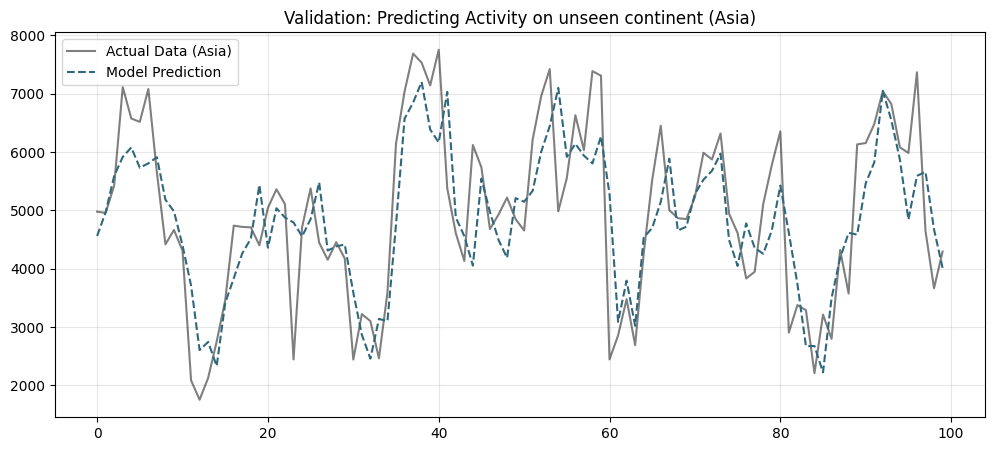

Validation Complete. RMSE on Unseen Data: 999.44


<Figure size 800x600 with 0 Axes>

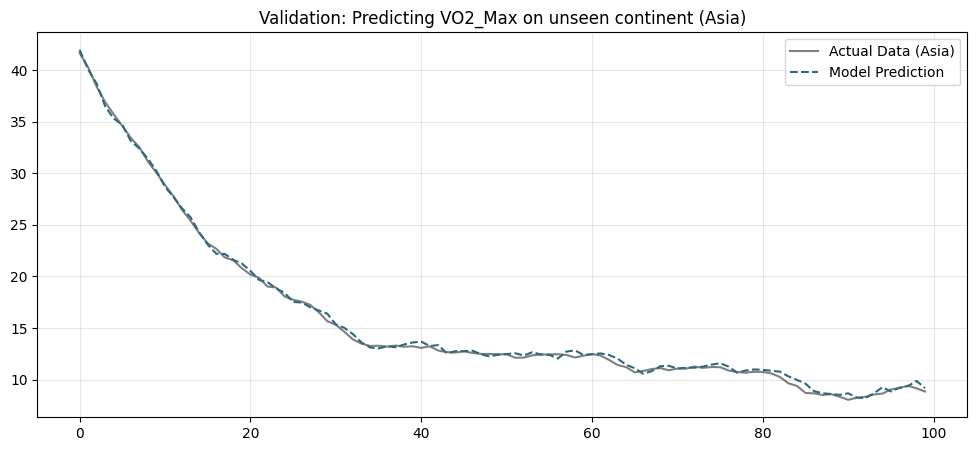

Validation Complete. RMSE on Unseen Data: 0.34


<Figure size 800x600 with 0 Axes>

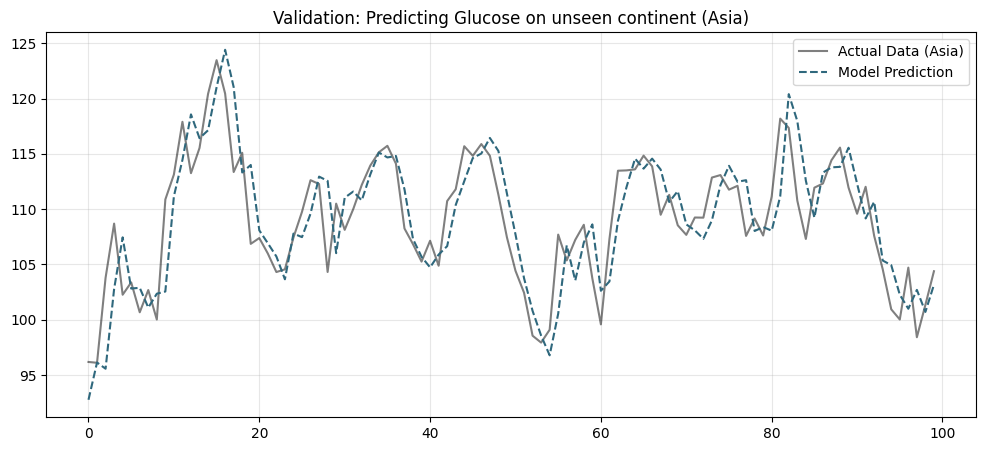

Validation Complete. RMSE on Unseen Data: 3.38


<Figure size 800x600 with 0 Axes>

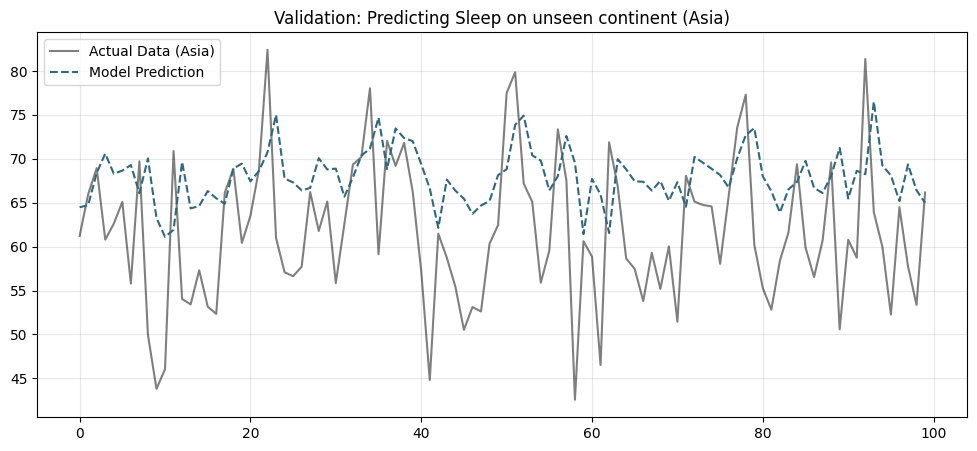

Validation Complete. RMSE on Unseen Data: 9.73


<Figure size 800x600 with 0 Axes>

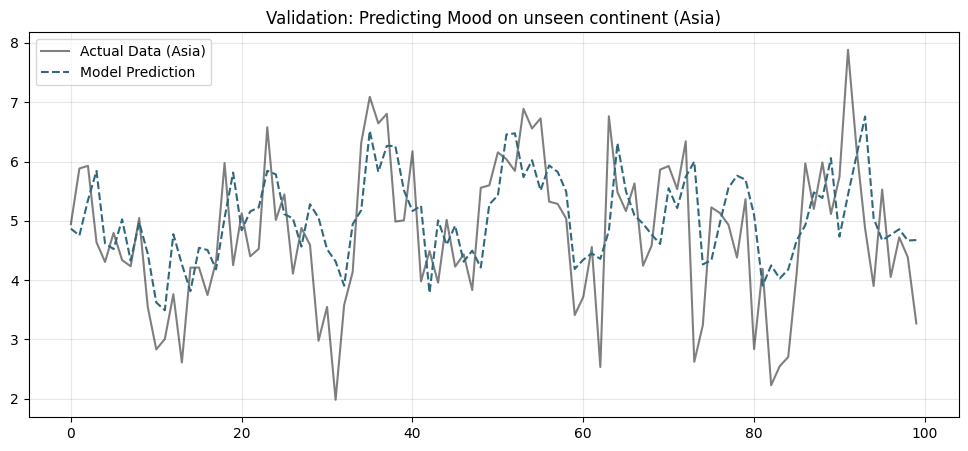

Validation Complete. RMSE on Unseen Data: 1.01


<Figure size 800x600 with 0 Axes>

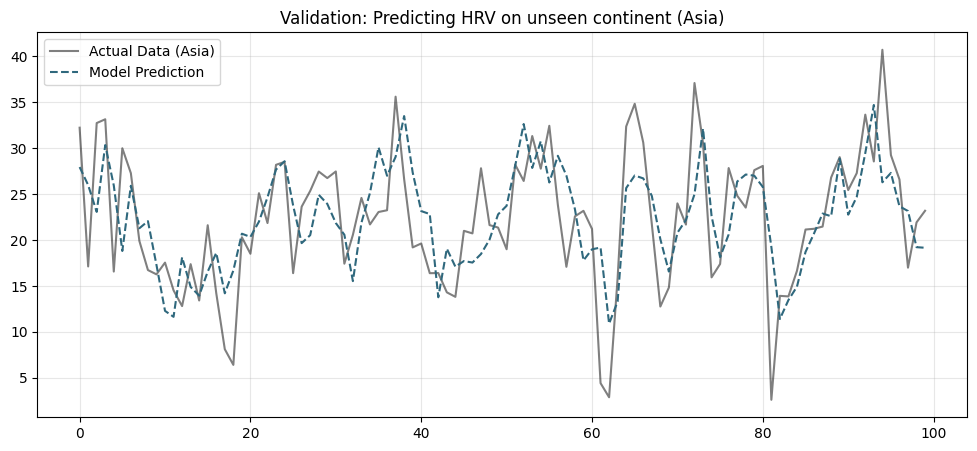

Validation Complete. RMSE on Unseen Data: 5.14


<Figure size 800x600 with 0 Axes>

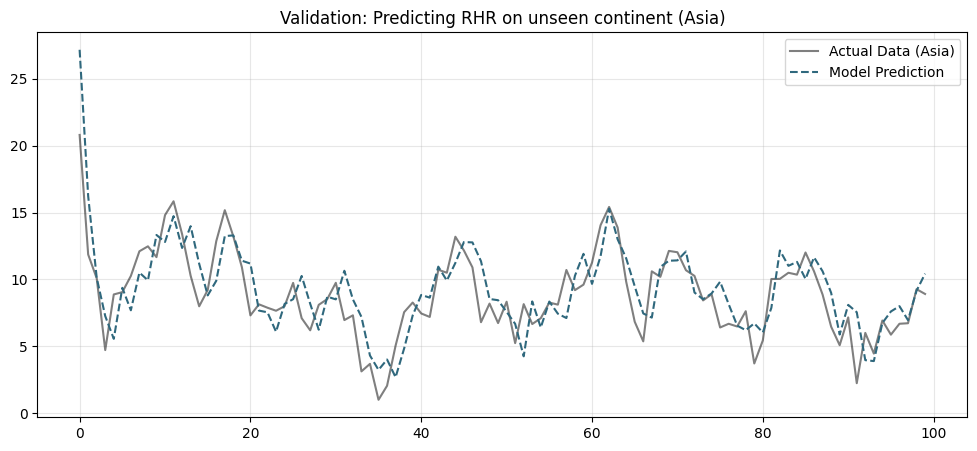

Validation Complete. RMSE on Unseen Data: 2.06


In [14]:

# STAGE 6: VALIDATION ON UNSEEN DATA
print("\nRunning Stage 6: Validation...")

# 1. Prepare Test Data
# We extract the raw numpy array to avoid the Index Warning you saw earlier.
test_values = df_test.values
lag_order = results.k_ar

predictions = []
actuals = []

# 2. Walk-Forward Validation
# For every day in the test set, use the previous 2 days (Lag 2) to predict today.
for i in range(lag_order, len(test_values)):
    # Input: The previous 'lag_order' days from the test set
    forecast_input = test_values[i-lag_order:i] 
    
    # Predict: The next single step
    pred = results.forecast(y=forecast_input, steps=1)
    
    predictions.append(pred[0])
    actuals.append(test_values[i])

# 3. Organize Results into DataFrames
pred_df = pd.DataFrame(predictions, columns=df_test.columns)
act_df = pd.DataFrame(actuals, columns=df_test.columns)

# 4. Visualize Accuracy (Focus on 'Activity')
def plot_validation(act_df, pred_df, variable):
    plt.figure(figsize=(12, 5))
    limit = 100 # Zoom in on the first 100 days for clarity
    plt.plot(act_df[variable][:limit].values, label='Actual Data (Asia)', color='black', alpha=0.5)
    plt.plot(pred_df[variable][:limit].values, label='Model Prediction', color='#2F687D', linestyle='--')
    plt.title(f"Validation: Predicting {variable} on unseen continent (Asia)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # 5. Score the Model
    rmse = np.sqrt(mean_squared_error(act_df[variable], pred_df[variable]))
    print(f"Validation Complete. RMSE on Unseen Data: {rmse:.2f}")

plot_validation(act_df, pred_df, 'Activity')
plt.figure(figsize=(8, 6))
plot_validation(act_df, pred_df, 'VO2_Max')
plt.figure(figsize=(8, 6))
plot_validation(act_df, pred_df, 'Glucose')
plt.figure(figsize=(8, 6))
plot_validation(act_df, pred_df, 'Sleep')
plt.figure(figsize=(8, 6))
plot_validation(act_df, pred_df, 'Mood')
plt.figure(figsize=(8, 6))
plot_validation(act_df, pred_df, 'HRV')
plt.figure(figsize=(8, 6))
plot_validation(act_df, pred_df, 'RHR')



Stage 5: Running baseline vs intervention simulations on health system...


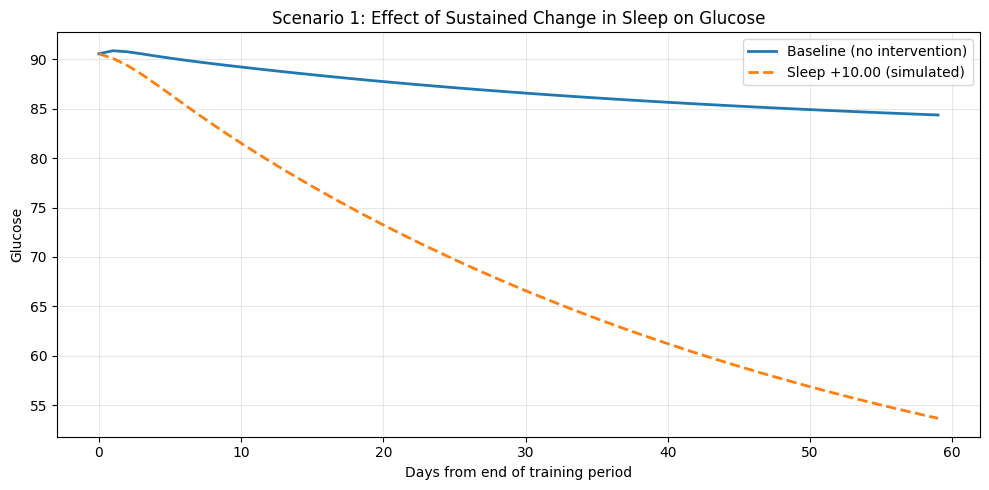


Sleep → Glucose threshold analysis:
  Threshold (above 110.0)
  Baseline crossing day:     None
  Intervention crossing day: None
  → Intervention does not improve threshold timing under this setup.


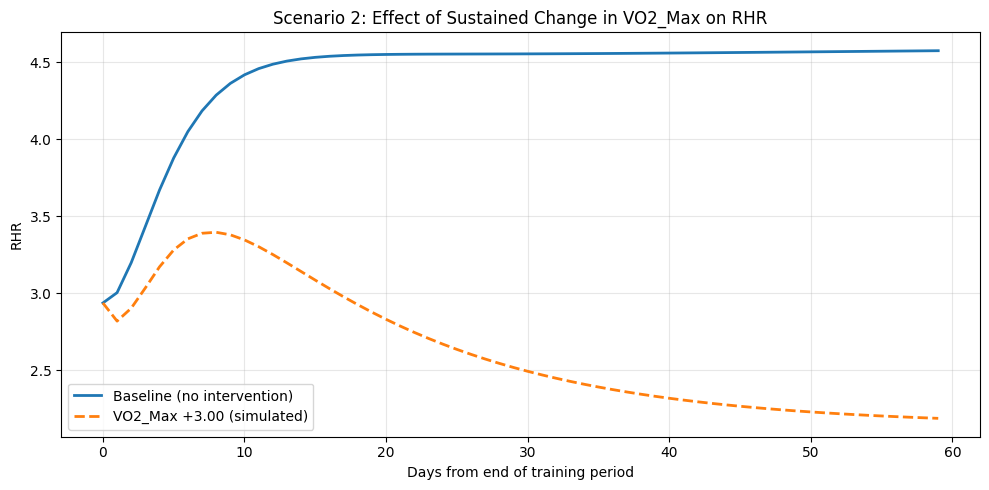


VO2_Max → RHR threshold analysis:
  Threshold (below 60.0)
  Baseline crossing day:     0
  Intervention crossing day: 0
  → Intervention does not improve threshold timing under this setup.


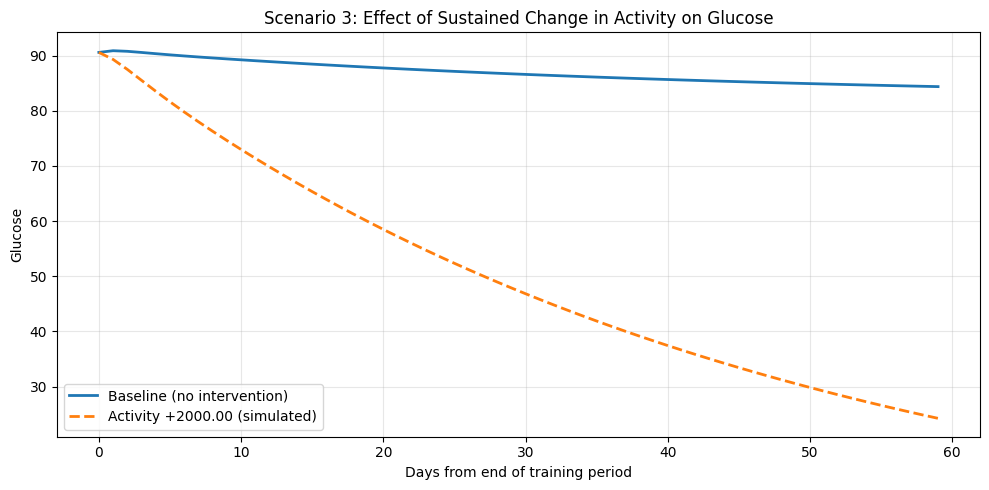


Activity → Glucose threshold analysis:
  Threshold (above 110.0)
  Baseline crossing day:     None
  Intervention crossing day: None
  → Intervention does not improve threshold timing under this setup.


(array([[7.62183355e+01, 6.44805371e+00, 5.51531256e+03, 2.93699220e+00,
         3.66065196e+01, 1.05924549e+01, 9.05792993e+01],
        [7.37568754e+01, 6.39811365e+00, 5.88063668e+03, 3.00390533e+00,
         3.57604478e+01, 1.07805673e+01, 9.08864734e+01],
        [7.32389723e+01, 6.30858816e+00, 6.07341085e+03, 3.19876994e+00,
         3.43490004e+01, 1.09097587e+01, 9.07789655e+01],
        [7.30104133e+01, 6.22651799e+00, 6.14004199e+03, 3.43444860e+00,
         3.33930440e+01, 1.10507941e+01, 9.05721176e+01],
        [7.28410339e+01, 6.17061297e+00, 6.14310988e+03, 3.67048989e+00,
         3.27889233e+01, 1.12010615e+01, 9.03494860e+01],
        [7.27066643e+01, 6.13509903e+00, 6.12153498e+03, 3.87856444e+00,
         3.23952727e+01, 1.13512238e+01, 9.01369592e+01],
        [7.26031243e+01, 6.11340458e+00, 6.09508369e+03, 4.04958377e+00,
         3.21314627e+01, 1.14962174e+01, 8.99382301e+01],
        [7.25255091e+01, 6.10038970e+00, 6.07199426e+03, 4.18400814e+00,
         3

In [15]:
# ============================================================
# STAGE 5: INTERVENTION SIMULATION (Baseline vs Policy Path)
# ============================================================

print("\nStage 5: Running baseline vs intervention simulations on health system...")

var_names = list(df_train.columns)
k_ar = results.k_ar


# -------------------------------------------------------------------
# Helper: generic forward simulation of the VAR
# -------------------------------------------------------------------
def simulate_path(results, initial_history, horizon, intervention_fn=None):
    """
    Simulate a path of length `horizon` from a VAR model.

    Parameters
    ----------
    results : statsmodels.tsa.vector_ar.var_model.VARResults
        Fitted VAR model.
    initial_history : np.ndarray, shape (k_ar, n_vars)
        Last k_ar observations (in correct time order).
    horizon : int
        Number of future steps to simulate.
    intervention_fn : callable or None
        Function f(step_idx, y_pred) -> modified_y_pred.
        Called at each step AFTER the VAR one-step prediction.
        If None, no intervention is applied.

    Returns
    -------
    path : np.ndarray, shape (horizon, n_vars)
        Simulated future path.
    """
    history = initial_history.copy()
    n_vars = history.shape[1]
    path = []

    for step in range(horizon):
        # One-step-ahead forecast from current history
        y_pred = results.forecast(y=history, steps=1)[0]  # shape (n_vars,)

        # Apply intervention (policy) if provided
        if intervention_fn is not None:
            y_pred = intervention_fn(step, y_pred.copy())

        path.append(y_pred)

        # Roll history window forward: drop oldest, append new
        history = np.vstack([history[1:], y_pred])

    return np.array(path)  # shape (horizon, n_vars)


# -------------------------------------------------------------------
# Helper: detect when a trajectory crosses a critical threshold
# -------------------------------------------------------------------
def first_crossing(series, threshold, direction="above"):
    """
    Return the first time index t where series crosses threshold.

    Parameters
    ----------
    series : 1D array-like
        Time series values.
    threshold : float
        Threshold value.
    direction : {'above', 'below'}
        'above'  => series[t] >= threshold
        'below'  => series[t] <= threshold

    Returns
    -------
    idx : int or None
        First index where condition is met, or None if never crosses.
    """
    series = np.asarray(series)
    if direction == "above":
        mask = series >= threshold
    else:
        mask = series <= threshold

    if not mask.any():
        return None

    return int(np.argmax(mask))


# -------------------------------------------------------------------
# Higher-level helper: run one driver→target intervention scenario
# -------------------------------------------------------------------
def run_intervention_scenario(
    results,
    df_train_ts,
    driver,
    target,
    delta,
    horizon=60,
    threshold=None,
    direction="above",
    title_prefix="Intervention"
):
    """
    Run a baseline vs intervention simulation for a single driver→target pair.

    Parameters
    ----------
    results : VARResults
        Fitted VAR model.
    df_train_ts : DataFrame
        Training time series with same columns as the VAR.
    driver : str
        Name of the variable to be "intervened" on (e.g. 'Sleep', 'VO2_Max').
    target : str
        Name of the variable whose response we plot (e.g. 'Glucose', 'RHR').
    delta : float
        Amount to add to `driver` at every future time step (conceptual
        "sustained improvement/worsening").
    horizon : int
        Number of days to simulate.
    threshold : float or None
        Critical threshold for the target (e.g. bad glucose level).
    direction : {'above','below'}
        Direction for threshold crossing.
    title_prefix : str
        Text to prefix the plot title with.

    Returns
    -------
    baseline_path : np.ndarray
    intervention_path : np.ndarray
    """
    var_names = list(df_train_ts.columns)
    if driver not in var_names or target not in var_names:
        print(f"Skipping scenario {driver}→{target}: variable not in VAR.")
        return None, None

    driver_idx = var_names.index(driver)
    target_idx = var_names.index(target)
    k_ar = results.k_ar

    # Last k_ar observations from TRAIN set as starting state
    initial_history = df_train_ts.values[-k_ar:, :]

    # Baseline: no intervention
    baseline_path = simulate_path(results, initial_history, horizon, intervention_fn=None)

    # Policy: sustained change in the driver variable
    def intervention_fn(step, y_pred):
        y_pred[driver_idx] += delta
        return y_pred

    intervention_path = simulate_path(results, initial_history, horizon, intervention_fn=intervention_fn)

    # Plot trajectories for the target variable
    t = np.arange(horizon)
    plt.figure(figsize=(10, 5))
    plt.plot(t, baseline_path[:, target_idx], label="Baseline (no intervention)", linewidth=2)
    plt.plot(
        t,
        intervention_path[:, target_idx],
        label=f"{driver} +{delta:.2f} (simulated)",
        linewidth=2,
        linestyle="--",
    )
    plt.xlabel("Days from end of training period")
    plt.ylabel(target)
    plt.title(f"{title_prefix}: Effect of Sustained Change in {driver} on {target}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Optional threshold analysis
    if threshold is not None:
        base_cross = first_crossing(baseline_path[:, target_idx], threshold, direction=direction)
        intv_cross = first_crossing(intervention_path[:, target_idx], threshold, direction=direction)

        print(f"\n{driver} → {target} threshold analysis:")
        print(f"  Threshold ({direction} {threshold})")
        print(f"  Baseline crossing day:     {base_cross}")
        print(f"  Intervention crossing day: {intv_cross}")

        if base_cross is not None and (intv_cross is None or
                                       (direction == 'above' and intv_cross > base_cross) or
                                       (direction == 'below' and intv_cross < base_cross)):
            print("  → Intervention delays or avoids crossing the threshold.")
        else:
            print("  → Intervention does not improve threshold timing under this setup.")

    return baseline_path, intervention_path


# Example scenarios for your synthetic health system

# 1) Better Sleep → lower Glucose
run_intervention_scenario(
    results,
    df_train,
    driver="Sleep",
    target="Glucose",
    delta=+10.0,          # e.g. +10 "sleep quality" units
    horizon=60,
    threshold=110.0,      # example: high glucose threshold
    direction="above",
    title_prefix="Scenario 1"
)

# 2) Higher VO2_Max → lower RHR
run_intervention_scenario(
    results,
    df_train,
    driver="VO2_Max",
    target="RHR",
    delta=+3.0,           # e.g. +3 ml/kg/min fitness gain
    horizon=60,
    threshold=60.0,       # "good" RHR threshold
    direction="below",
    title_prefix="Scenario 2"
)

# 3) More Activity → lower Glucose
run_intervention_scenario(
    results,
    df_train,
    driver="Activity",
    target="Glucose",
    delta=+2000.0,        # +2000 steps per day (for example)
    horizon=60,
    threshold=110.0,
    direction="above",
    title_prefix="Scenario 3"
)
